In [1]:
# 1. Load library 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer 

from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import Ridge

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("D:\VedGrow_ML_02\dataset\AmesHousing.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [3]:
# Data Cleaning

numeric_columns = df.select_dtypes(include = np.number).columns

categorical_columns = df.select_dtypes(exclude= np.number).columns

num_imputer = SimpleImputer(strategy = 'median')
cat_imputer = SimpleImputer(strategy = 'most_frequent')

df[numeric_columns] = num_imputer.fit_transform(df[numeric_columns])

df[categorical_columns] = cat_imputer.fit_transform(df[categorical_columns])

In [4]:
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)

IQR = Q3 - Q1

df = df[
    (df['SalePrice'] >= Q1 - 1.5*IQR) &
    (df['SalePrice'] <= Q3 + 1.5*IQR)
]

In [5]:
# Feature Engineering

df["HouseAge"] = df["Yr Sold"] - df["Year Built"]

df["TotalBath"] = (
    df["Full Bath"] + 0.5*df["Half Bath"] + df["Bsmt Full Bath"] + 0.5*df["Bsmt Half Bath"]
)

In [6]:
df = pd.get_dummies(df, drop_first = True)

In [7]:
# Feature Selection

corr = df.corr()

target_corr = corr["SalePrice"].abs().sort_values(ascending = False)

selected = target_corr[target_corr > 0.30]

selected

SalePrice               1.000000
Overall Qual            0.785878
Gr Liv Area             0.652255
TotalBath               0.633780
Garage Cars             0.631196
Garage Area             0.605579
Exter Qual_TA           0.599523
Year Built              0.592549
HouseAge                0.592428
Exter Qual_Gd           0.580111
Full Bath               0.565246
Year Remod/Add          0.562002
Garage Finish_Unf       0.554984
Total Bsmt SF           0.549660
Kitchen Qual_TA         0.542369
Foundation_PConc        0.537383
1st Flr SF              0.531070
Bsmt Qual_TA            0.525505
Garage Yr Blt           0.518461
Kitchen Qual_Gd         0.479778
Fireplaces              0.462706
TotRms AbvGrd           0.428873
Bsmt Qual_Gd            0.413888
Garage Type_Detchd      0.395244
Exterior 1st_VinylSd    0.374523
Exterior 2nd_VinylSd    0.368064
BsmtFin Type 1_GLQ      0.364464
Mas Vnr Area            0.354364
Heating QC_TA           0.347327
MS Zoning_RM            0.336102
Foundation

In [8]:
features = selected.index.drop("SalePrice")

X = df[features]

y = df["SalePrice"]

In [9]:
# Train Test Split

X_train,X_test,y_train,y_test = train_test_split( X, y, test_size = 0.2, random_state = 42)

In [10]:
# Feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [11]:
# Linear regression Model

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [12]:
# ridge Model

ridge = Ridge(alpha = 10)

ridge.fit(X_train_scaled,y_train)

ridge_pred = ridge.predict(X_test_scaled)

In [13]:
# Random Forest Model

rf = RandomForestRegressor(
    n_estimators = 300,
    random_state = 42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [14]:
# Evaluation Function

def evaluate(y_true,y_pred):

    mae = mean_absolute_error(y_true,y_pred)

    rmse = np.sqrt(mean_squared_error(y_true,y_pred))

    r2 = r2_score(y_true,y_pred)

    return mae,rmse,r2

In [17]:
# Compare Model

models = {
    "Linear Regression": lr_pred,
    "Ridge Regression": ridge_pred,
    "Random Forest": rf_pred
}

for name,pred in models.items():
    mae,rmse,r2 = evaluate(y_test,pred)

    print(name)
    
    print("MAE :",mae)

    print("RMSE:",rmse)

    print("R2 :",r2)

    print()

Linear Regression
MAE : 17081.765235862626
RMSE: 25782.925314426724
R2 : 0.8212542282156754

Ridge Regression
MAE : 17096.719743790818
RMSE: 25796.45246204211
R2 : 0.8210666191916095

Random Forest
MAE : 14743.198690689158
RMSE: 21410.001640143502
R2 : 0.8767449286757122



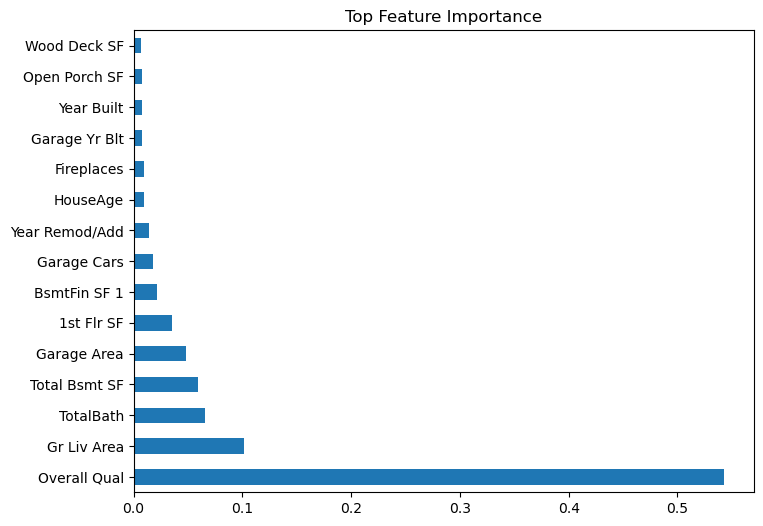

In [18]:
# Feature Importance
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

importance.head(15).plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Top Feature Importance")

plt.show()

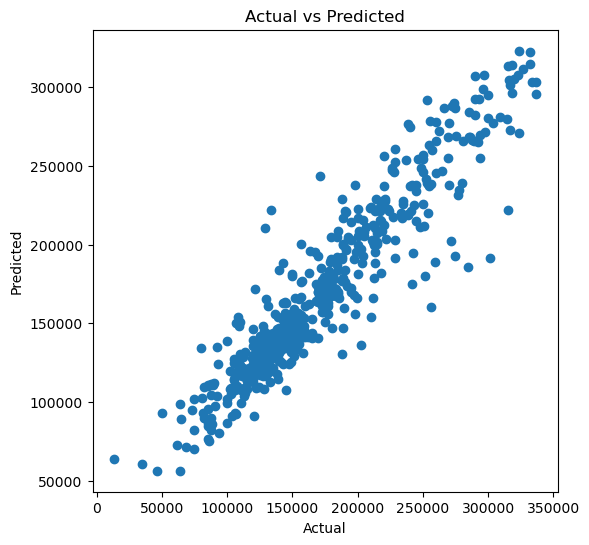

In [19]:
# Actual vs Predicted

plt.figure(figsize=(6,6))

plt.scatter(y_test,rf_pred)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

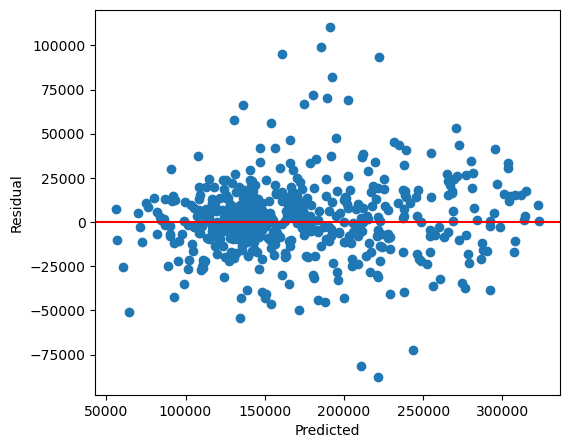

In [20]:
# Residual Plot
residual = y_test-rf_pred

plt.figure(figsize=(6,5))

plt.scatter(rf_pred,residual)

plt.axhline(0,color="red")

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.show()